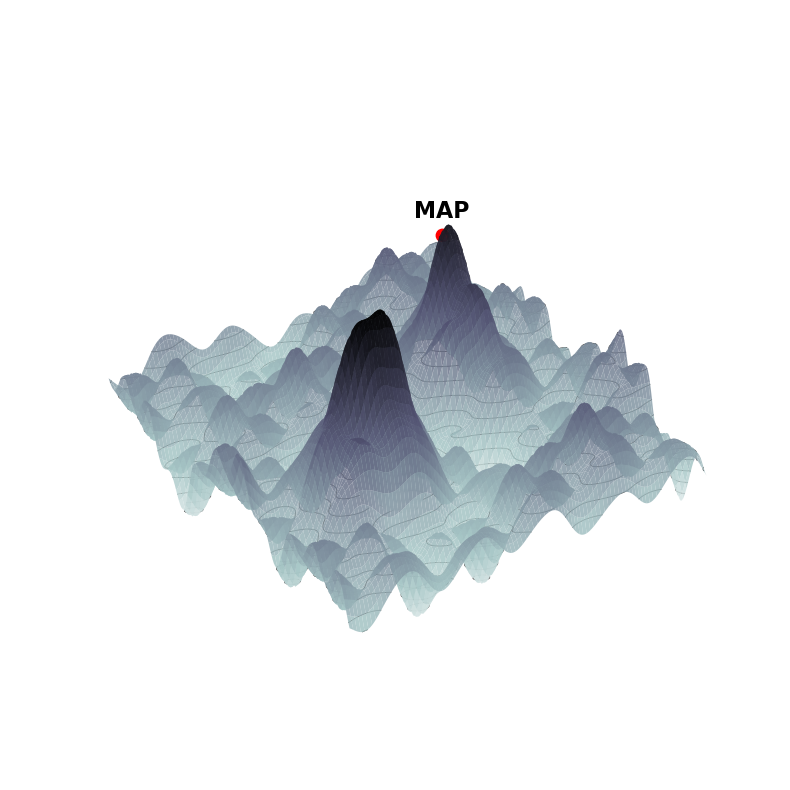

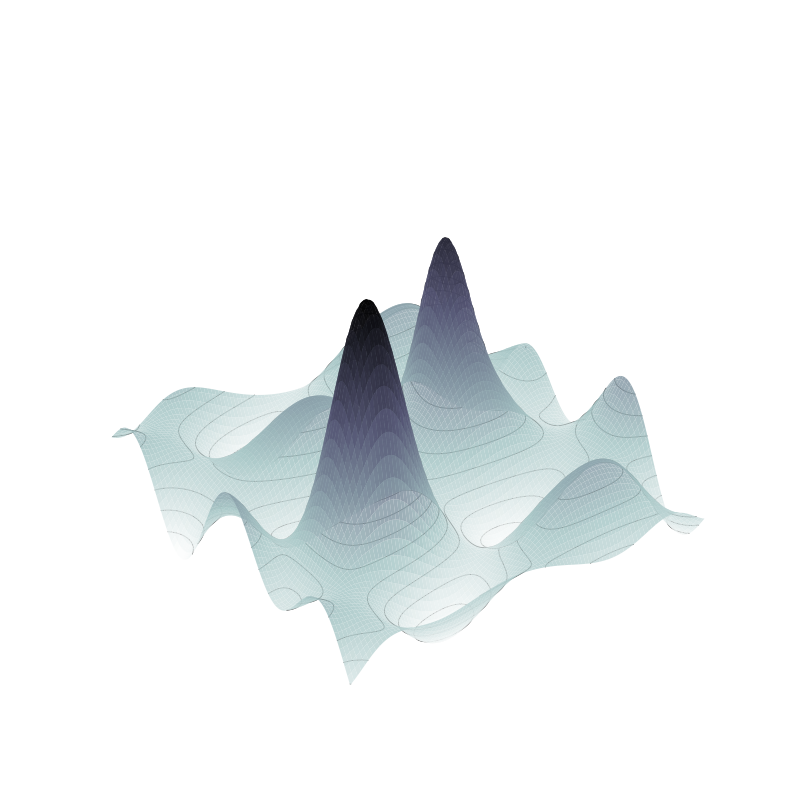

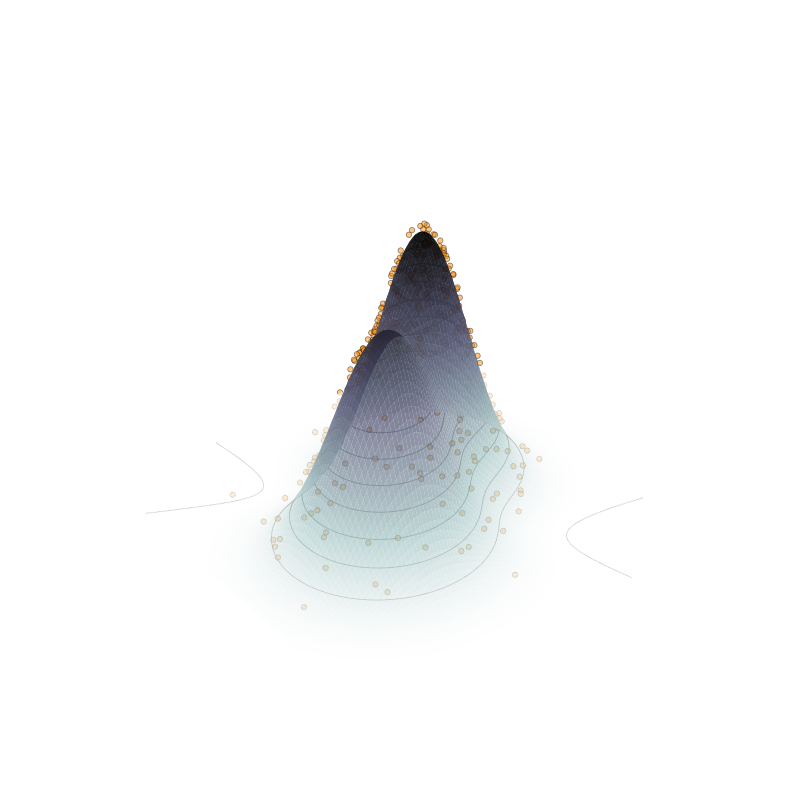

Both bimodal landscape figures saved successfully at 500 DPI.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# --- Revised Figure 1 (MAP / Original Chaotic Landscape) - NOW COMPLICATED ---
# =============================================================================
def highly_complicated_map_landscape(X, Y):
    # 1. Base Structure: Still contains the underlying bimodal/valley structure
    #    to ensure a deep valley exists, but made more extreme.
    z = 3.2 * np.exp(-((X - 3.2)**2 / 1.8 + (Y - 2.2)**2 / 2.5))  # MAP Peak
    z += 2.8 * np.exp(-((X + 3.5)**2 / 3.0 + (Y + 2.5)**2 / 2.8)) # Secondary Peak
    z -= 2.0 * np.exp(-((X + Y)**2 / 2.0 + (X - Y)**2 / 20.0))    # Deep diagonal valley

    # 2. Add high-frequency, chaotic oscillations (Sine & Cosine waves)
    #    This creates "hundred peaks" and severe topological ripples, layered on
    #    top of the base distribution, but significantly more extreme than
    #    simple noise. We use multiple interlocking frequencies.
    z += 0.8 * np.sin(0.5 * X) * np.cos(1 * Y)
    z += 0.6 * np.cos(1.0 * X - 2.0 * Y) * np.sin(X + 2.0 * Y)
    z += 0.4 * np.sin(X) * np.cos(Y) * np.sin(3.0 * (X+Y))

    # 3. Add global gentle waves and a non-linear scaling to break periodicity
    z += 0.3 * np.cos(0.4 * X) * np.sin(0.5 * Y)
    z += 0.2 * np.cos(X**2 / 10 + Y / 2.0)

    # Shift baseline up and normalize for visual consistency
    z += 2.2
    return z

def likelihood_landscape(X, Y):
    # 1. Base Structure: Still contains the underlying bimodal/valley structure
    #    to ensure a deep valley exists, but made more extreme.
    z = 3.2 * np.exp(-((X - 3.2)**2 / 1.8 + (Y - 2.2)**2 / 2.5))  # MAP Peak
    z += 2.8 * np.exp(-((X + 3.5)**2 / 3.0 + (Y + 2.5)**2 / 2.8)) # Secondary Peak

    # 2. Add high-frequency, chaotic oscillations (Sine & Cosine waves)
    #    This creates "hundred peaks" and severe topological ripples, layered on
    #    top of the base distribution, but significantly more extreme than
    #    simple noise. We use multiple interlocking frequencies.
    z += 0.8 * np.sin(0.5 * X) * np.cos(1 * Y)

    # 3. Add global gentle waves and a non-linear scaling to break periodicity
    z += 0.3 * np.cos(0.4 * X) * np.sin(0.5 * Y)
    z += 0.2 * np.cos(X**2 / 10 + Y / 2.0)

    # Shift baseline up and normalize for visual consistency
    z += 2.2
    return z


x1 = np.linspace(-8, 8, 200)
y1 = np.linspace(-8, 8, 200)
X1, Y1 = np.meshgrid(x1, y1)
Z1 = highly_complicated_map_landscape(X1, Y1)

fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')

# Plot the surface and a denser set of contour lines to show the chaos
ax1.plot_surface(X1, Y1, Z1, cmap='bone_r', alpha=0.85, edgecolor='none', rstride=2, cstride=2)
# Using 20 levels (instead of 12) to visualize all the new small peaks and false minima
ax1.contour(X1, Y1, Z1, levels=20, colors='black', linewidths=0.6, alpha=0.7)

# Add MAP point and label to the *highest* peak in the chaotic landscape
# The peak has slightly shifted due to the complex superposition.
map_x, map_y = 3.2, 2.2 # updated coordinates for new peak
map_z = highly_complicated_map_landscape(map_x, map_y)
ax1.scatter([map_x], [map_y], [map_z], color='red', s=80, zorder=5)
ax1.text(map_x, map_y, map_z + 0.35, "MAP", color='black', fontsize=16, fontweight='bold', ha='center')

# Save the new complicated Figure 1 with a new, descriptive filename
ax1.set_axis_off()
ax1.view_init(elev=35, azim=-125)
plt.tight_layout()
plt.savefig("original_map_landscape_chaotic.png", format='png', dpi=500, transparent=True)
plt.show()

# =============================================================================
# 1.5. likelihood landscape: intermediate complexity
# =============================================================================
Z1_likelihood = likelihood_landscape(X1, Y1)

fig1_likelihood = plt.figure(figsize=(10, 8))
ax1_likelihood = fig1_likelihood.add_subplot(111, projection='3d')
ax1_likelihood.plot_surface(X1, Y1, Z1_likelihood, cmap='bone_r', alpha=0.85, edgecolor='none', rstride=2, cstride=2)
ax1_likelihood.contour(X1, Y1, Z1_likelihood, levels=20, colors='black', linewidths=0.6, alpha=0.7)
ax1_likelihood.set_axis_off()
ax1_likelihood.view_init(elev=35, azim=-125)
plt.tight_layout()
plt.savefig("likelihood_landscape_chaotic.png", format='png', dpi=500, transparent=True)
plt.show()


# =============================================================================
# 2. Preconditioned Landscape: Warped by Static Hessian with HMC Samples
# =============================================================================
def preconditioned_landscape(X, Y):
    # Peak 1 (formerly MAP) - The static Hessian makes this area isotropic (rounded)
    z = 3.0 * np.exp(-((X - 1.5)**2 / 6 + (Y - 1)**2 / 6))
    # Peak 2 - Pulled closer and wider, but the bimodal structure survives
    z += 2.5 * np.exp(-((X + 2)**2 / 8 + (Y + 1.5)**2 / 7))
    # Valley is much shallower and easier for the leapfrog integrator to cross
    z -= 0.5 * np.exp(-((X + Y)**2 / 6 + (X - Y)**2 / 20))
    return z + 1.5

x2 = np.linspace(-8, 8, 200)
y2 = np.linspace(-8, 8, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = preconditioned_landscape(X2, Y2)

fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')

ax2.plot_surface(X2, Y2, Z2, cmap='bone_r', alpha=0.75, edgecolor='none', rstride=2, cstride=2)
ax2.contour(X2, Y2, Z2, levels=12, colors='black', linewidths=0.6, alpha=0.5)

# Generate HMC samples matching the bimodal density
num_samples = 400
# 60% of samples around the primary peak, 40% around the secondary peak
samples_x = np.concatenate([np.random.normal(1.5, np.sqrt(3), 240), np.random.normal(-2, np.sqrt(4), 160)])
samples_y = np.concatenate([np.random.normal(1, np.sqrt(3), 240), np.random.normal(-1.5, np.sqrt(3.5), 160)])

# Filter samples strictly within the viewing grid
valid = (samples_x > -7.5) & (samples_x < 7.5) & (samples_y > -7.5) & (samples_y < 7.5)
samples_x = samples_x[valid]
samples_y = samples_y[valid]

# Map samples to surface height with a small offset
samples_z = preconditioned_landscape(samples_x, samples_y) + 0.1

# Scatter points at 50% transparency
ax2.scatter(samples_x, samples_y, samples_z, color='darkorange', s=15, alpha=0.5, edgecolor='black', linewidth=0.5, zorder=5)

ax2.set_axis_off()
ax2.view_init(elev=35, azim=-125)
plt.tight_layout()
plt.savefig("preconditioned_bimodal_hmc.png", format='png', dpi=500, transparent=True)
plt.show()

print("Both bimodal landscape figures saved successfully at 500 DPI.")